<a href="https://colab.research.google.com/github/Hamidali936/WEB_TASK_ONE/blob/main/Assignment_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1 — Setup & Data Loading
### 1.1 Import Libraries
We begin by importing all required libraries and configuring plot aesthetics.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print("✅ All libraries loaded successfully.")
print(f"pandas  version: {pd.__version__}")
print(f"numpy   version: {np.__version__}")

✅ All libraries loaded successfully.
pandas  version: 2.2.2
numpy   version: 2.0.2


### 1.2 Load the Dataset — Task 1, Q1


In [ ]:
# Load dataset
df = pd.read_csv('messyData.csv')

print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("First 10 rows:")
df.head(10)

DATASET SHAPE
Rows   : 275,000
Columns: 10

First 10 rows:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,NaN,NaN,NaN,2.0,NaN,NaN,Netherlands,No,1.0,120569.0
1,NaN,16.0,Diploma,NaN,Media,NaN,Remote,NaN,NaN,105757.0
2,NaN,18.0,Bachelor,9.0,Manufacturing,Enterprise,Sweden,No,NaN,180750.0
3,NaN,NaN,Master,NaN,NaN,Small,Singapore,Hybrid,NaN,101968.0
4,NaN,7.0,Master,NaN,Education,NaN,Remote,No,NaN,162627.0
5,AI Engineer,15.0,High School,NaN,NaN,Medium,NaN,NaN,3.0,NaN
6,DevOps Engineer,NaN,Master,3.0,Education,Medium,India,NaN,5.0,123306.0
7,Backend Developer,2.0,Diploma,10.0,Finance,Medium,Sweden,Yes,0.0,NaN
8,Cybersecurity Analyst,NaN,High School,19.0,Government,Startup,NaN,NaN,1.0,NaN
9,NaN,NaN,NaN,19.0,Technology,NaN,NaN,No,NaN,129377.0


### 1.3 Data Types & Column Info — Task 1, Q2
We run `df.info()` to inspect data types, non-null counts, and memory usage.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275000 entries, 0 to 274999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   job_title         137347 non-null  object 
 1   experience_years  137418 non-null  float64
 2   education_level   137575 non-null  object 
 3   skills_count      137695 non-null  float64
 4   industry          137650 non-null  object 
 5   company_size      137783 non-null  object 
 6   location          137442 non-null  object 
 7   remote_work       137127 non-null  object 
 8   certifications    137133 non-null  float64
 9   salary            137851 non-null  float64
dtypes: float64(4), object(6)
memory usage: 21.0+ MB


### 1.4 Descriptive Statistics — Task 1, Q3
> **Key salary stats:** Mean ≈ $186,428 | Median ≈ $184,499 | Std Dev ≈ $54,720


In [ ]:
# Full descriptive statistics
print(df.describe(include='all').to_string())

                job_title  experience_years education_level   skills_count industry company_size location remote_work  certifications         salary
count              137347     137418.000000          137575  137695.000000   137650       137783   137442      137127   137133.000000  137851.000000
unique                 12               NaN               5            NaN       10            5       10           3             NaN            NaN
top     Backend Developer               NaN          Master            NaN  Finance        Large   Remote          No             NaN            NaN
freq                11626               NaN           27652            NaN    13974        27732    13969       45943             NaN            NaN
mean                  NaN         10.022595             NaN       9.994241      NaN          NaN      NaN         NaN        2.489328  145738.688395
std                   NaN          6.060026             NaN       5.479228      NaN          NaN      NaN 

In [ ]:
# Salary-specific stats
print("=" * 50)
print("SALARY STATISTICS")
print("=" * 50)
print(f"Mean   : ${df['salary'].mean():,.2f}")
print(f"Median : ${df['salary'].median():,.2f}")
print(f"Std Dev: ${df['salary'].std():,.2f}")
print(f"Min    : ${df['salary'].min():,.2f}")
print(f"Max    : ${df['salary'].max():,.2f}")

SALARY STATISTICS
Mean   : $145,738.69
Median : $143,550.00
Std Dev: $37,421.70
Min    : $31,867.00
Max    : $328,616.00


### 1.5 Column Classification — Task 1, Q4


In [ ]:
# Classify columns
numerical_cols   = ['experience_years','skills_count','certifications','salary']
categorical_cols = ['job_title','education_level','industry',
                    'company_size','location','remote_work']

print(f"{'Column':<22} {'Type':<14} {'Unique':>8} {'Missing %':>10}")
print("-" * 60)
for col in df.columns:
    ctype    = 'Numerical'   if col in numerical_cols else 'Categorical'
    unique   = df[col].nunique()
    miss_pct = df[col].isnull().mean() * 100
    print(f"{col:<22} {ctype:<14} {unique:>8} {miss_pct:>9.1f}%")

Column                 Type             Unique  Missing %
------------------------------------------------------------
job_title              Categorical          12      50.1%
experience_years       Numerical            21      50.0%
education_level        Categorical           5      50.0%
skills_count           Numerical            19      49.9%
industry               Categorical          10      49.9%
company_size           Categorical           5      49.9%
location               Categorical          10      50.0%
remote_work            Categorical           3      50.1%
certifications         Numerical             6      50.1%
salary                 Numerical         82315      49.9%


### 1.6 CHALLENGE: 1% Sample Comparison — Task 1, Q5


In [ ]:
sample_df = df.sample(frac=0.01, random_state=42)
print(f"Full dataset rows : {len(df):,}")
print(f"1% sample rows    : {len(sample_df):,}")
print()

for col in ['experience_years','skills_count','certifications','salary']:
    fm = df[col].mean(); sm = sample_df[col].mean()
    diff_pct = abs(fm-sm)/fm*100
    flag = '✅ similar' if diff_pct < 2 else '⚠️ different'
    print(f"{col:<22} Full mean={fm:>10.2f}  Sample mean={sm:>10.2f}  Diff={diff_pct:.2f}% {flag}")

Full dataset rows : 275,000
1% sample rows    : 2,750

experience_years       Full mean=     10.02  Sample mean=      9.86  Diff=1.61% ✅ similar
skills_count           Full mean=      9.99  Sample mean=     10.22  Diff=2.25% ⚠️ different
certifications         Full mean=      2.49  Sample mean=      2.44  Diff=1.93% ✅ similar
salary                 Full mean= 145738.69  Sample mean= 144782.80  Diff=0.66% ✅ similar


---
## Section 2 — Exploratory Data Analysis (EDA)
### 2.1 Missing Value Analysis


In [ ]:
# Missing value quantification
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct.round(2)
}).sort_values('Missing %', ascending=False)
print(missing_df.to_string())

                  Missing Count  Missing %
remote_work              137873      50.14
certifications           137867      50.13
job_title                137653      50.06
experience_years         137582      50.03
location                 137558      50.02
education_level          137425      49.97
industry                 137350      49.95
skills_count             137305      49.93
company_size             137217      49.90
salary                   137149      49.87


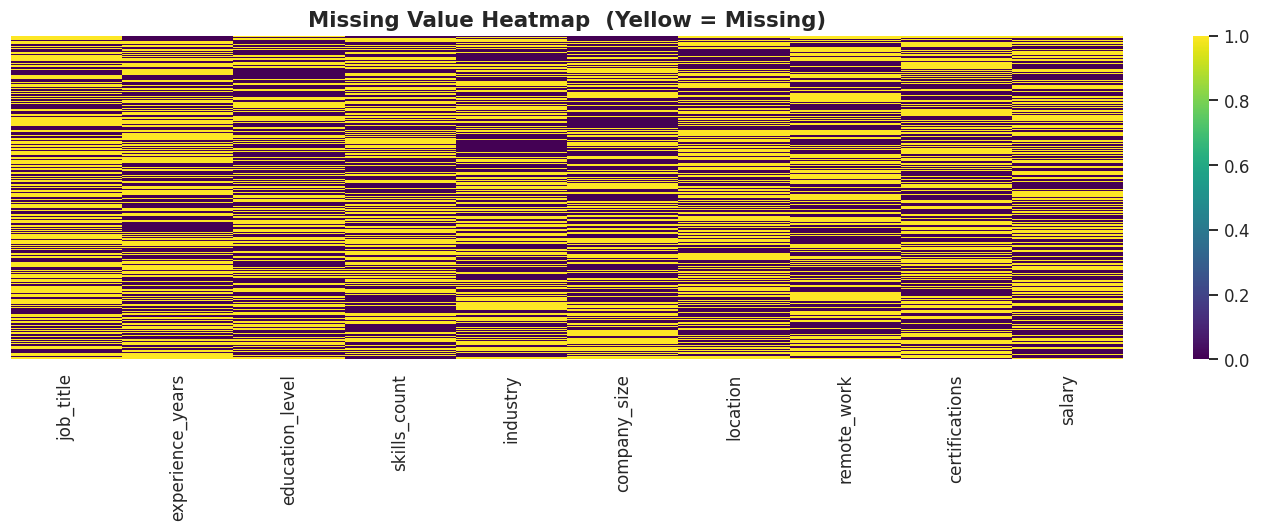

In [ ]:
# Missing Value Heatmap
plt.figure(figsize=(13, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Value Heatmap  (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Salary Distribution — Task 2, Q1


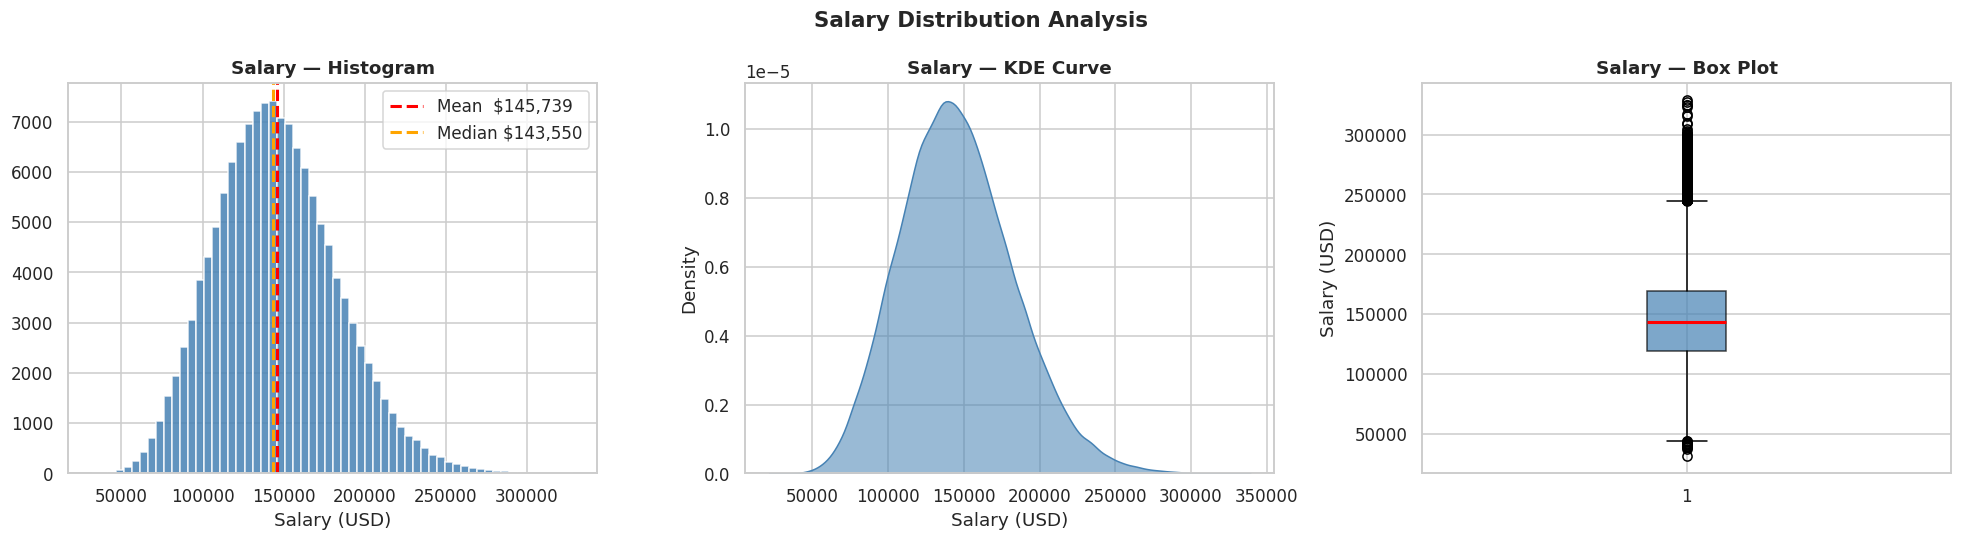

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sal_clean = df['salary'].dropna()

# Histogram
axes[0].hist(sal_clean, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(sal_clean.mean(),   color='red',    linestyle='--', lw=2,
                label=f'Mean  ${sal_clean.mean():,.0f}')
axes[0].axvline(sal_clean.median(), color='orange', linestyle='--', lw=2,
                label=f'Median ${sal_clean.median():,.0f}')
axes[0].set_title('Salary — Histogram', fontweight='bold')
axes[0].set_xlabel('Salary (USD)'); axes[0].legend()

# KDE
sns.kdeplot(sal_clean, ax=axes[1], fill=True, color='steelblue', alpha=0.55)
axes[1].set_title('Salary — KDE Curve', fontweight='bold')
axes[1].set_xlabel('Salary (USD)')

# Box plot
axes[2].boxplot(sal_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Salary — Box Plot', fontweight='bold')
axes[2].set_ylabel('Salary (USD)')
plt.suptitle('Salary Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.3 All Numerical Feature Distributions


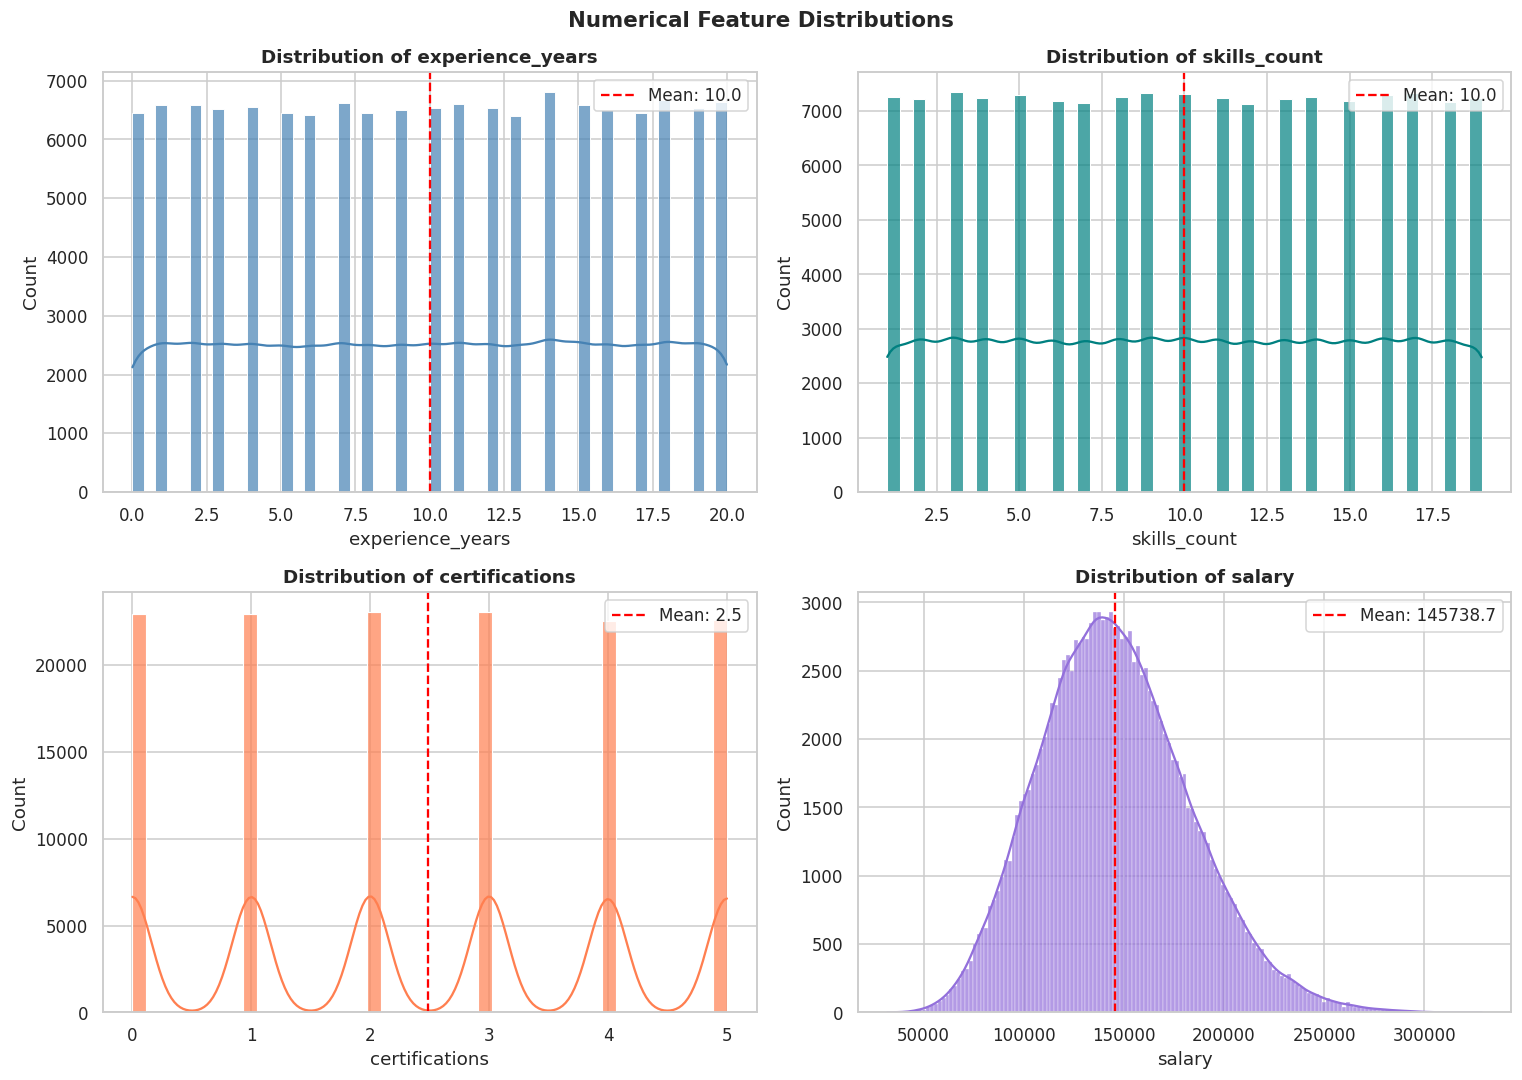

In [ ]:
num_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
colors   = ['steelblue', 'teal', 'coral', 'mediumpurple']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=colors[i], alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].legend()
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.4 All Categorical Feature Distributions


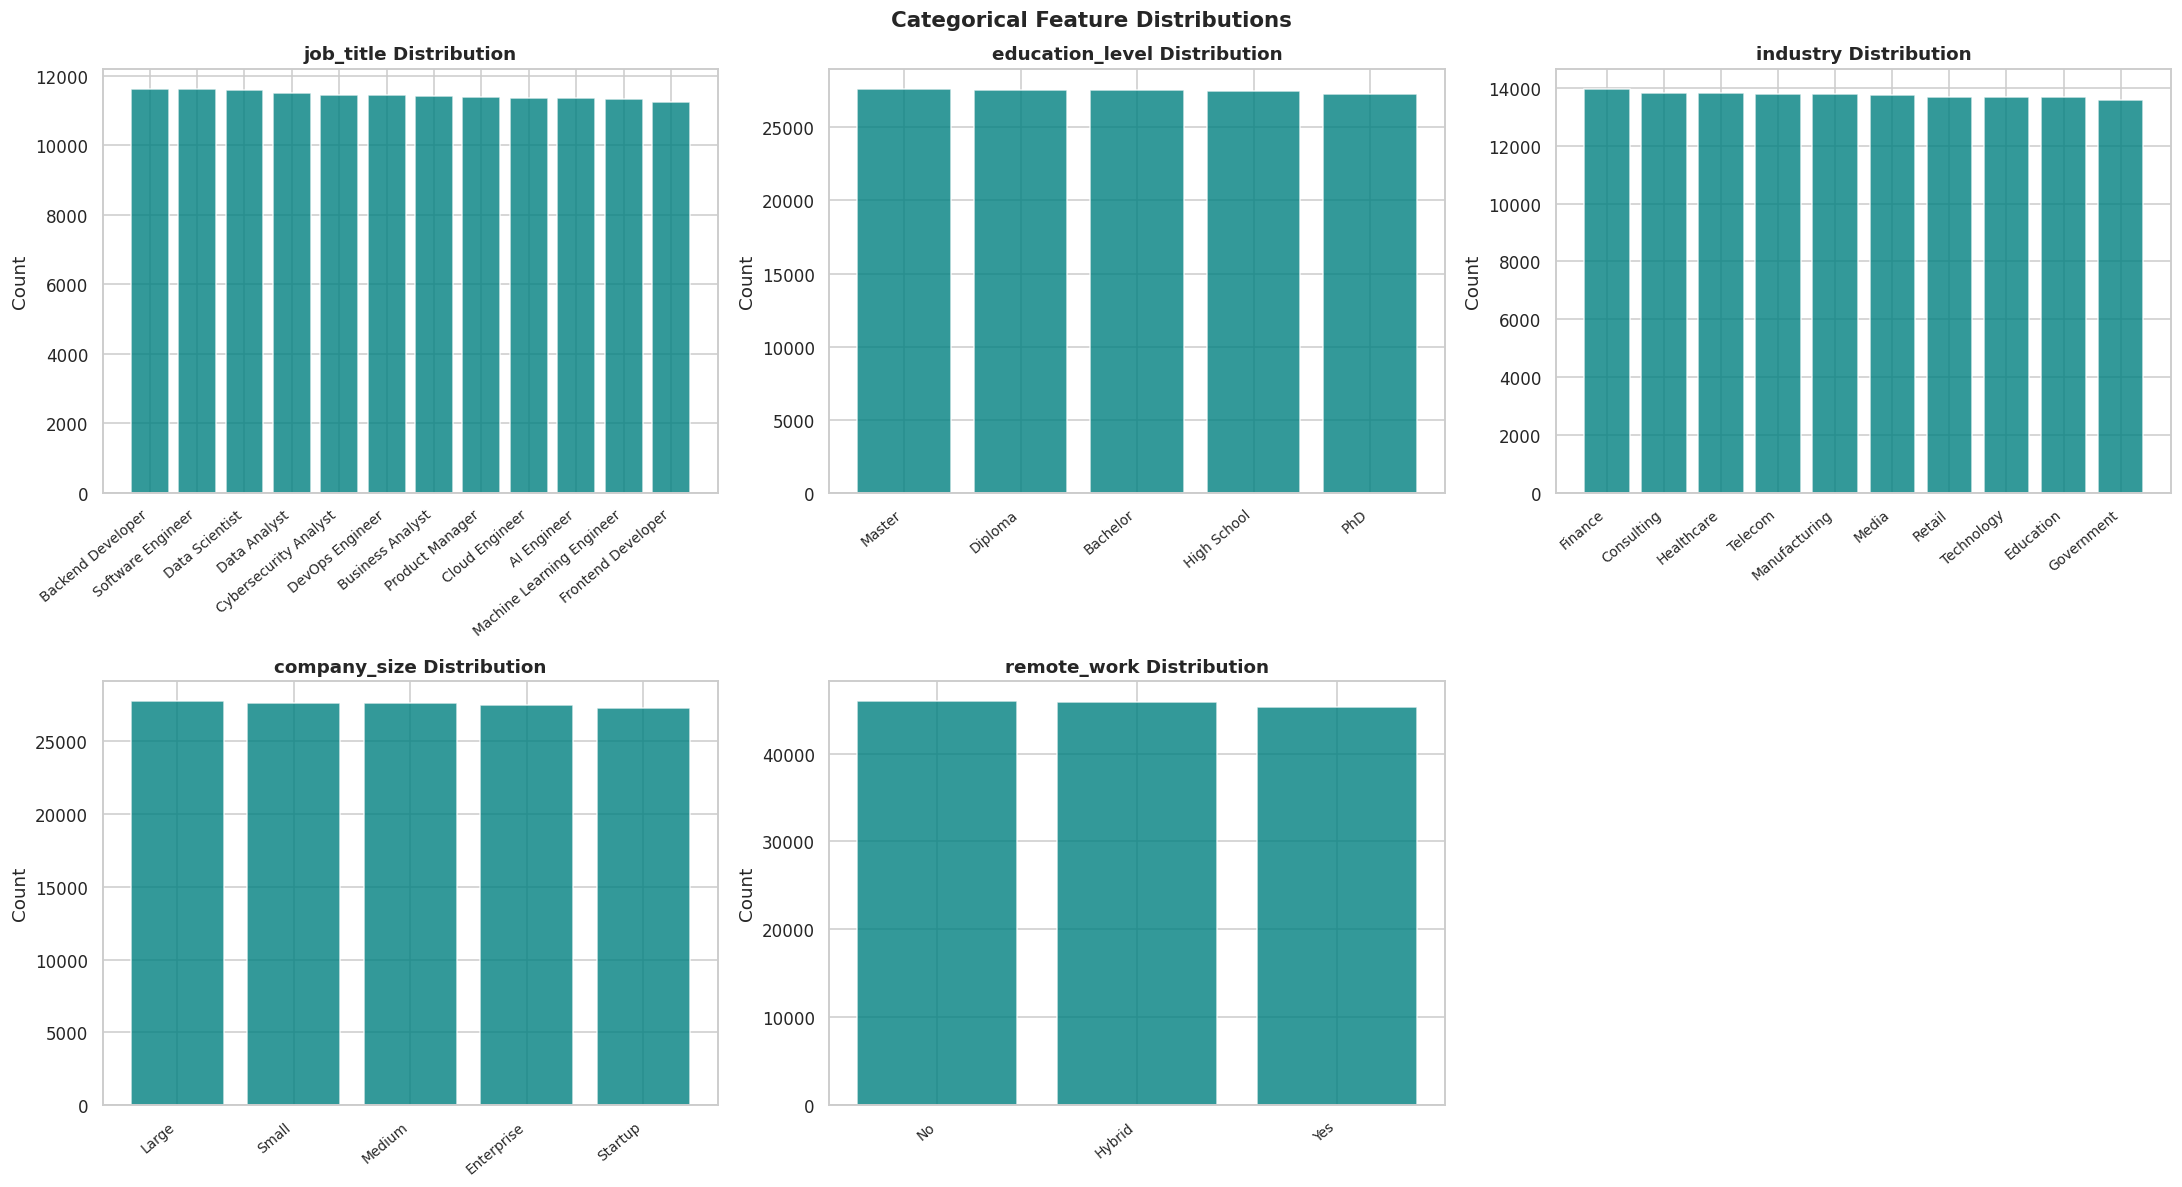

In [ ]:
cat_cols = ['job_title','education_level','industry','company_size','remote_work']
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(range(len(counts)), counts.values, color='teal', alpha=0.8, edgecolor='white')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=40, ha='right', fontsize=9)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_ylabel('Count')
axes[5].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.5 Average Salary by Job Title — Task 2, Q2


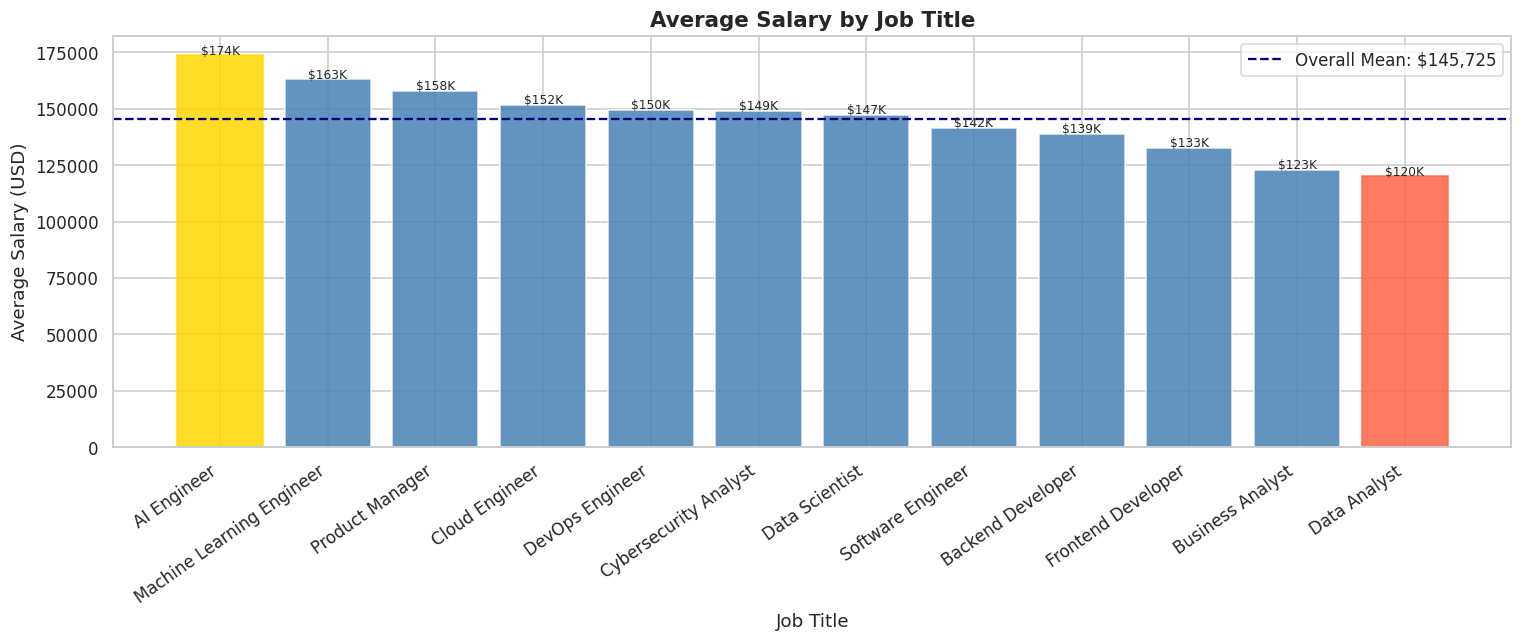

🥇 Highest: AI Engineer  — $173,713
🔻 Lowest : Data Analyst — $120,046


In [ ]:
avg_sal_job = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(avg_sal_job)), avg_sal_job.values,
              color='steelblue', edgecolor='white', alpha=0.85)
bars[0].set_color('gold'); bars[-1].set_color('tomato')
ax.set_xticks(range(len(avg_sal_job)))
ax.set_xticklabels(avg_sal_job.index, rotation=35, ha='right')
ax.set_title('Average Salary by Job Title', fontsize=14, fontweight='bold')
ax.set_xlabel('Job Title'); ax.set_ylabel('Average Salary (USD)')
ax.axhline(avg_sal_job.mean(), color='navy', linestyle='--',
           label=f'Overall Mean: ${avg_sal_job.mean():,.0f}')
ax.legend()
for i, v in enumerate(avg_sal_job.values):
    ax.text(i, v+500, f'${v/1000:.0f}K', ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print(f"🥇 Highest: {avg_sal_job.index[0]}  — ${avg_sal_job.iloc[0]:,.0f}")
print(f"🔻 Lowest : {avg_sal_job.index[-1]} — ${avg_sal_job.iloc[-1]:,.0f}")

### 2.6 Salary vs Numerical Features — Scatter + Trend Lines — Task 2, Q3


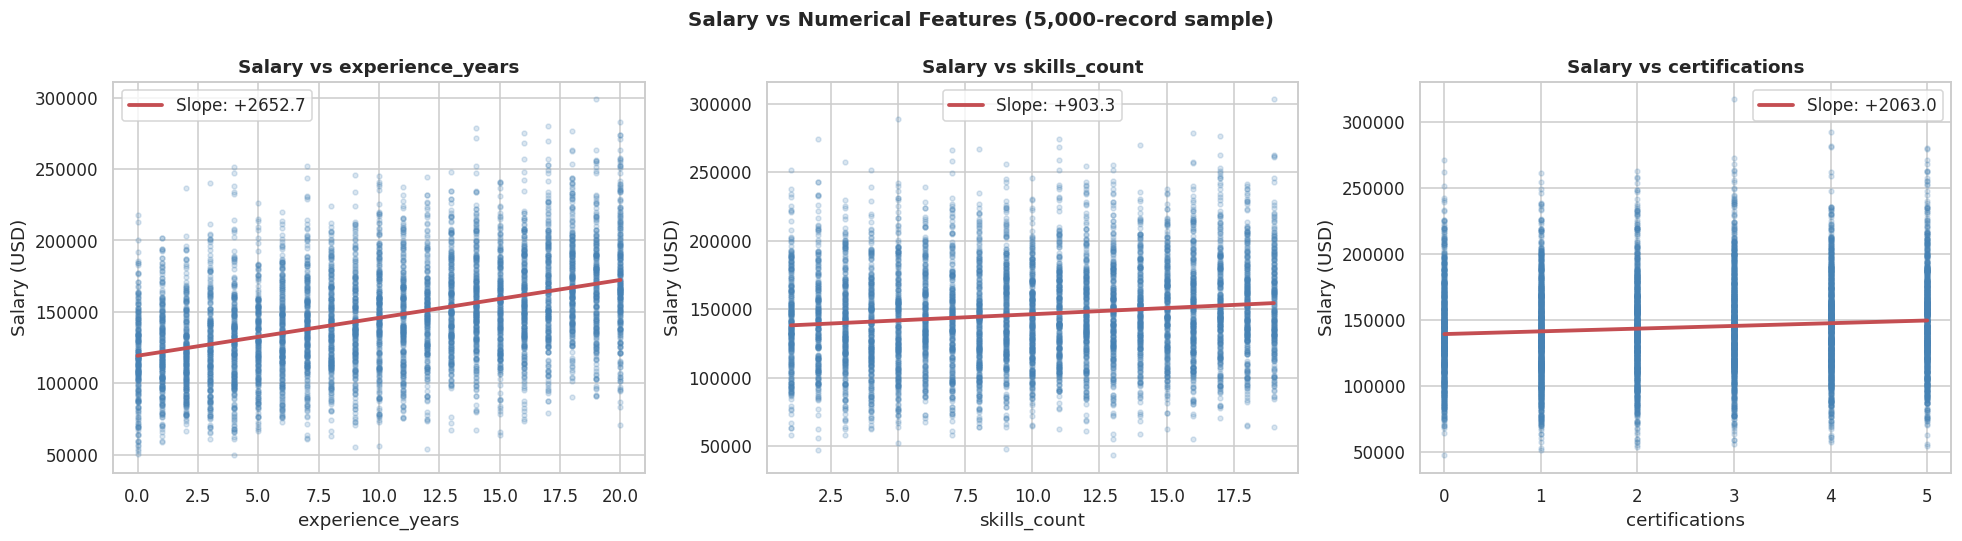

In [ ]:
num_feats = ['experience_years', 'skills_count', 'certifications']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_feats):
    samp = df[['salary', col]].dropna().sample(5000, random_state=42)
    axes[i].scatter(samp[col], samp['salary'], alpha=0.2, color='steelblue', s=10)
    z = np.polyfit(samp[col], samp['salary'], 1)
    p = np.poly1d(z)
    xr = np.linspace(samp[col].min(), samp[col].max(), 200)
    axes[i].plot(xr, p(xr), 'r-', lw=2.5, label=f'Slope: {z[0]:+.1f}')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Salary (USD)')
    axes[i].set_title(f'Salary vs {col}', fontweight='bold')
    axes[i].legend()
plt.suptitle('Salary vs Numerical Features (5,000-record sample)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.7 Correlation Heatmap — Task 2, Q4


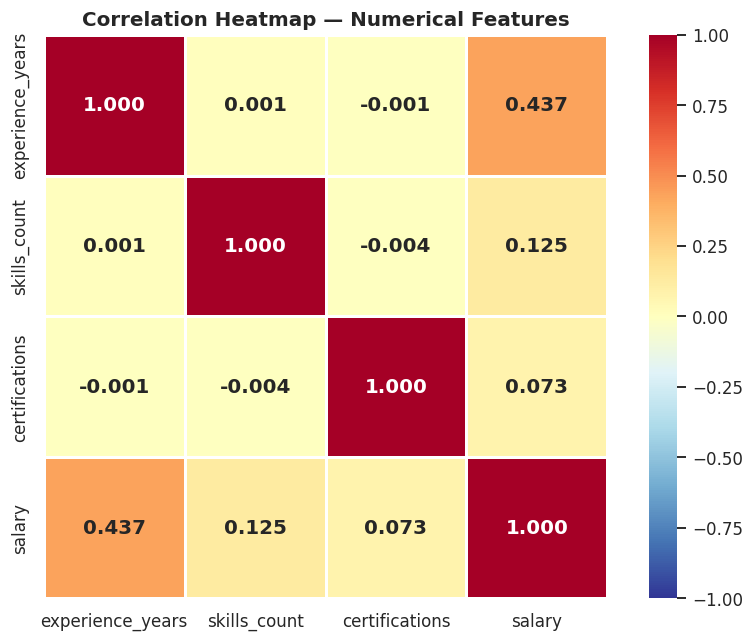


--- Correlation with SALARY ---
  experience_years    : +0.4374
  skills_count        : +0.1253
  certifications      : +0.0728


In [ ]:
corr_matrix = df[['experience_years','skills_count','certifications','salary']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            square=True, linewidths=0.8, vmin=-1, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n--- Correlation with SALARY ---")
sal_corr = corr_matrix['salary'].drop('salary').sort_values(ascending=False)
for feat, val in sal_corr.items():
    print(f"  {feat:<20}: {val:+.4f}")

### 2.8 Salary by Education Level — Task 2, Q5


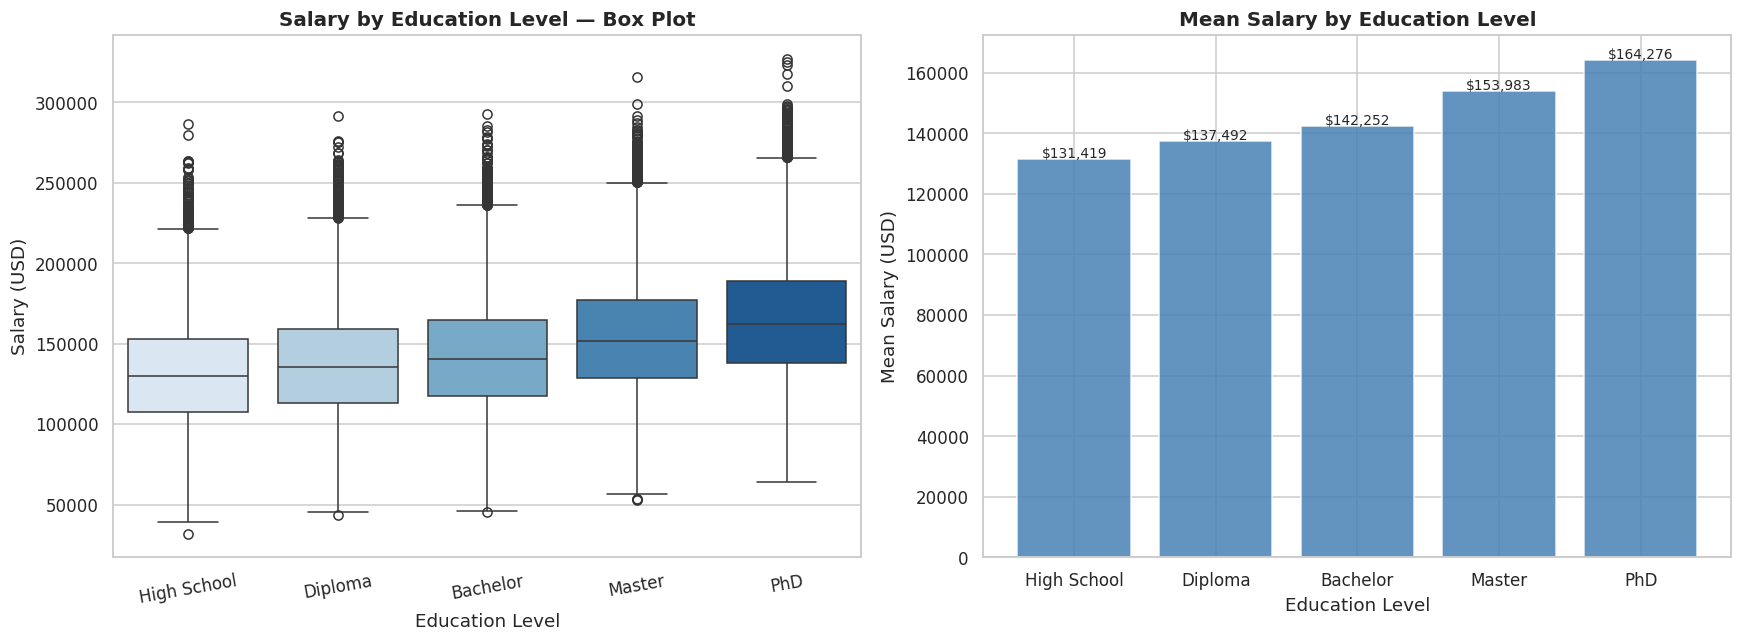


--- Mean Salary by Education Level ---
  High School    : $131,419
  Diploma        : $137,492
  Bachelor       : $142,252
  Master         : $153,983
  PhD            : $164,276


In [ ]:
edu_order = ['High School','Diploma','Bachelor','Master','PhD']
edu_order = [e for e in edu_order if e in df['education_level'].dropna().unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='education_level', y='salary', order=edu_order,
            palette='Blues', ax=axes[0])
axes[0].set_title('Salary by Education Level — Box Plot', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education Level'); axes[0].set_ylabel('Salary (USD)')
axes[0].tick_params(axis='x', rotation=10)

mean_edu = df.groupby('education_level')['salary'].mean().reindex(edu_order)
axes[1].bar(edu_order, mean_edu.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Mean Salary by Education Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education Level'); axes[1].set_ylabel('Mean Salary (USD)')
for i, v in enumerate(mean_edu.values):
    axes[1].text(i, v+500, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print("\n--- Mean Salary by Education Level ---")
for edu, val in mean_edu.items():
    print(f"  {edu:<15}: ${val:,.0f}")

### 2.9 Salary by Company Size, Remote Work & Industry


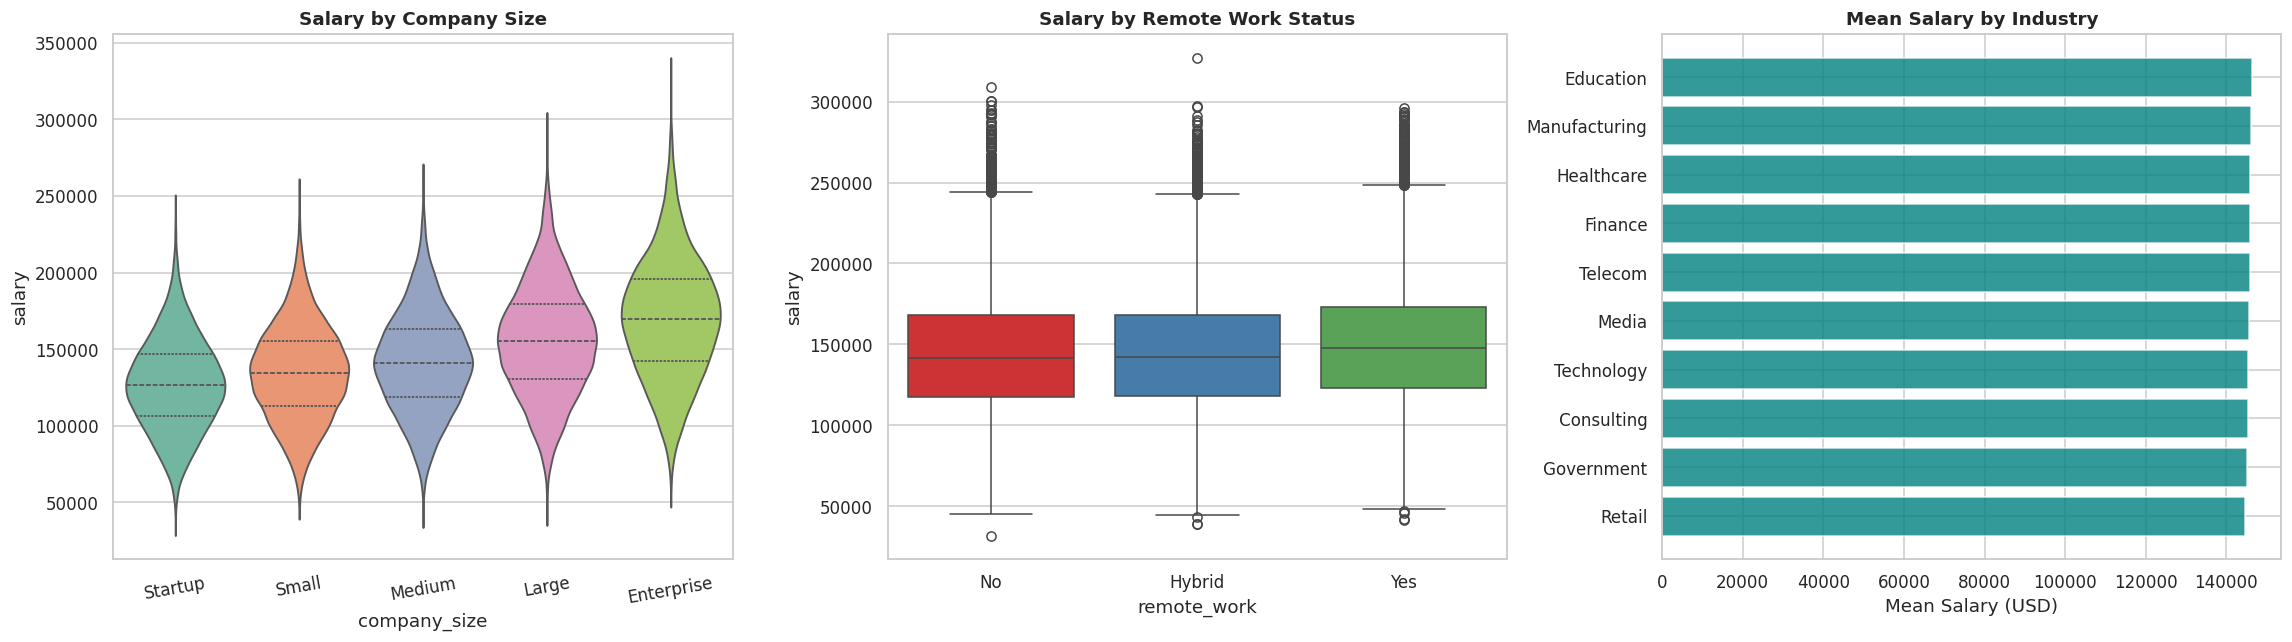

In [ ]:
size_order   = ['Startup','Small','Medium','Large','Enterprise']
remote_order = ['No','Hybrid','Yes']
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.violinplot(data=df, x='company_size', y='salary', order=size_order,
               palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Salary by Company Size', fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)
sns.boxplot(data=df, x='remote_work', y='salary', order=remote_order,
            palette='Set1', ax=axes[1])
axes[1].set_title('Salary by Remote Work Status', fontweight='bold')
ind_mean = df.groupby('industry')['salary'].mean().sort_values()
axes[2].barh(ind_mean.index, ind_mean.values, color='teal', alpha=0.8, edgecolor='white')
axes[2].set_title('Mean Salary by Industry', fontweight='bold')
axes[2].set_xlabel('Mean Salary (USD)')
plt.tight_layout(); plt.show()

### 2.10 CHALLENGE — Faceted Plot: Job Title × Remote Work — Task 2, Q6


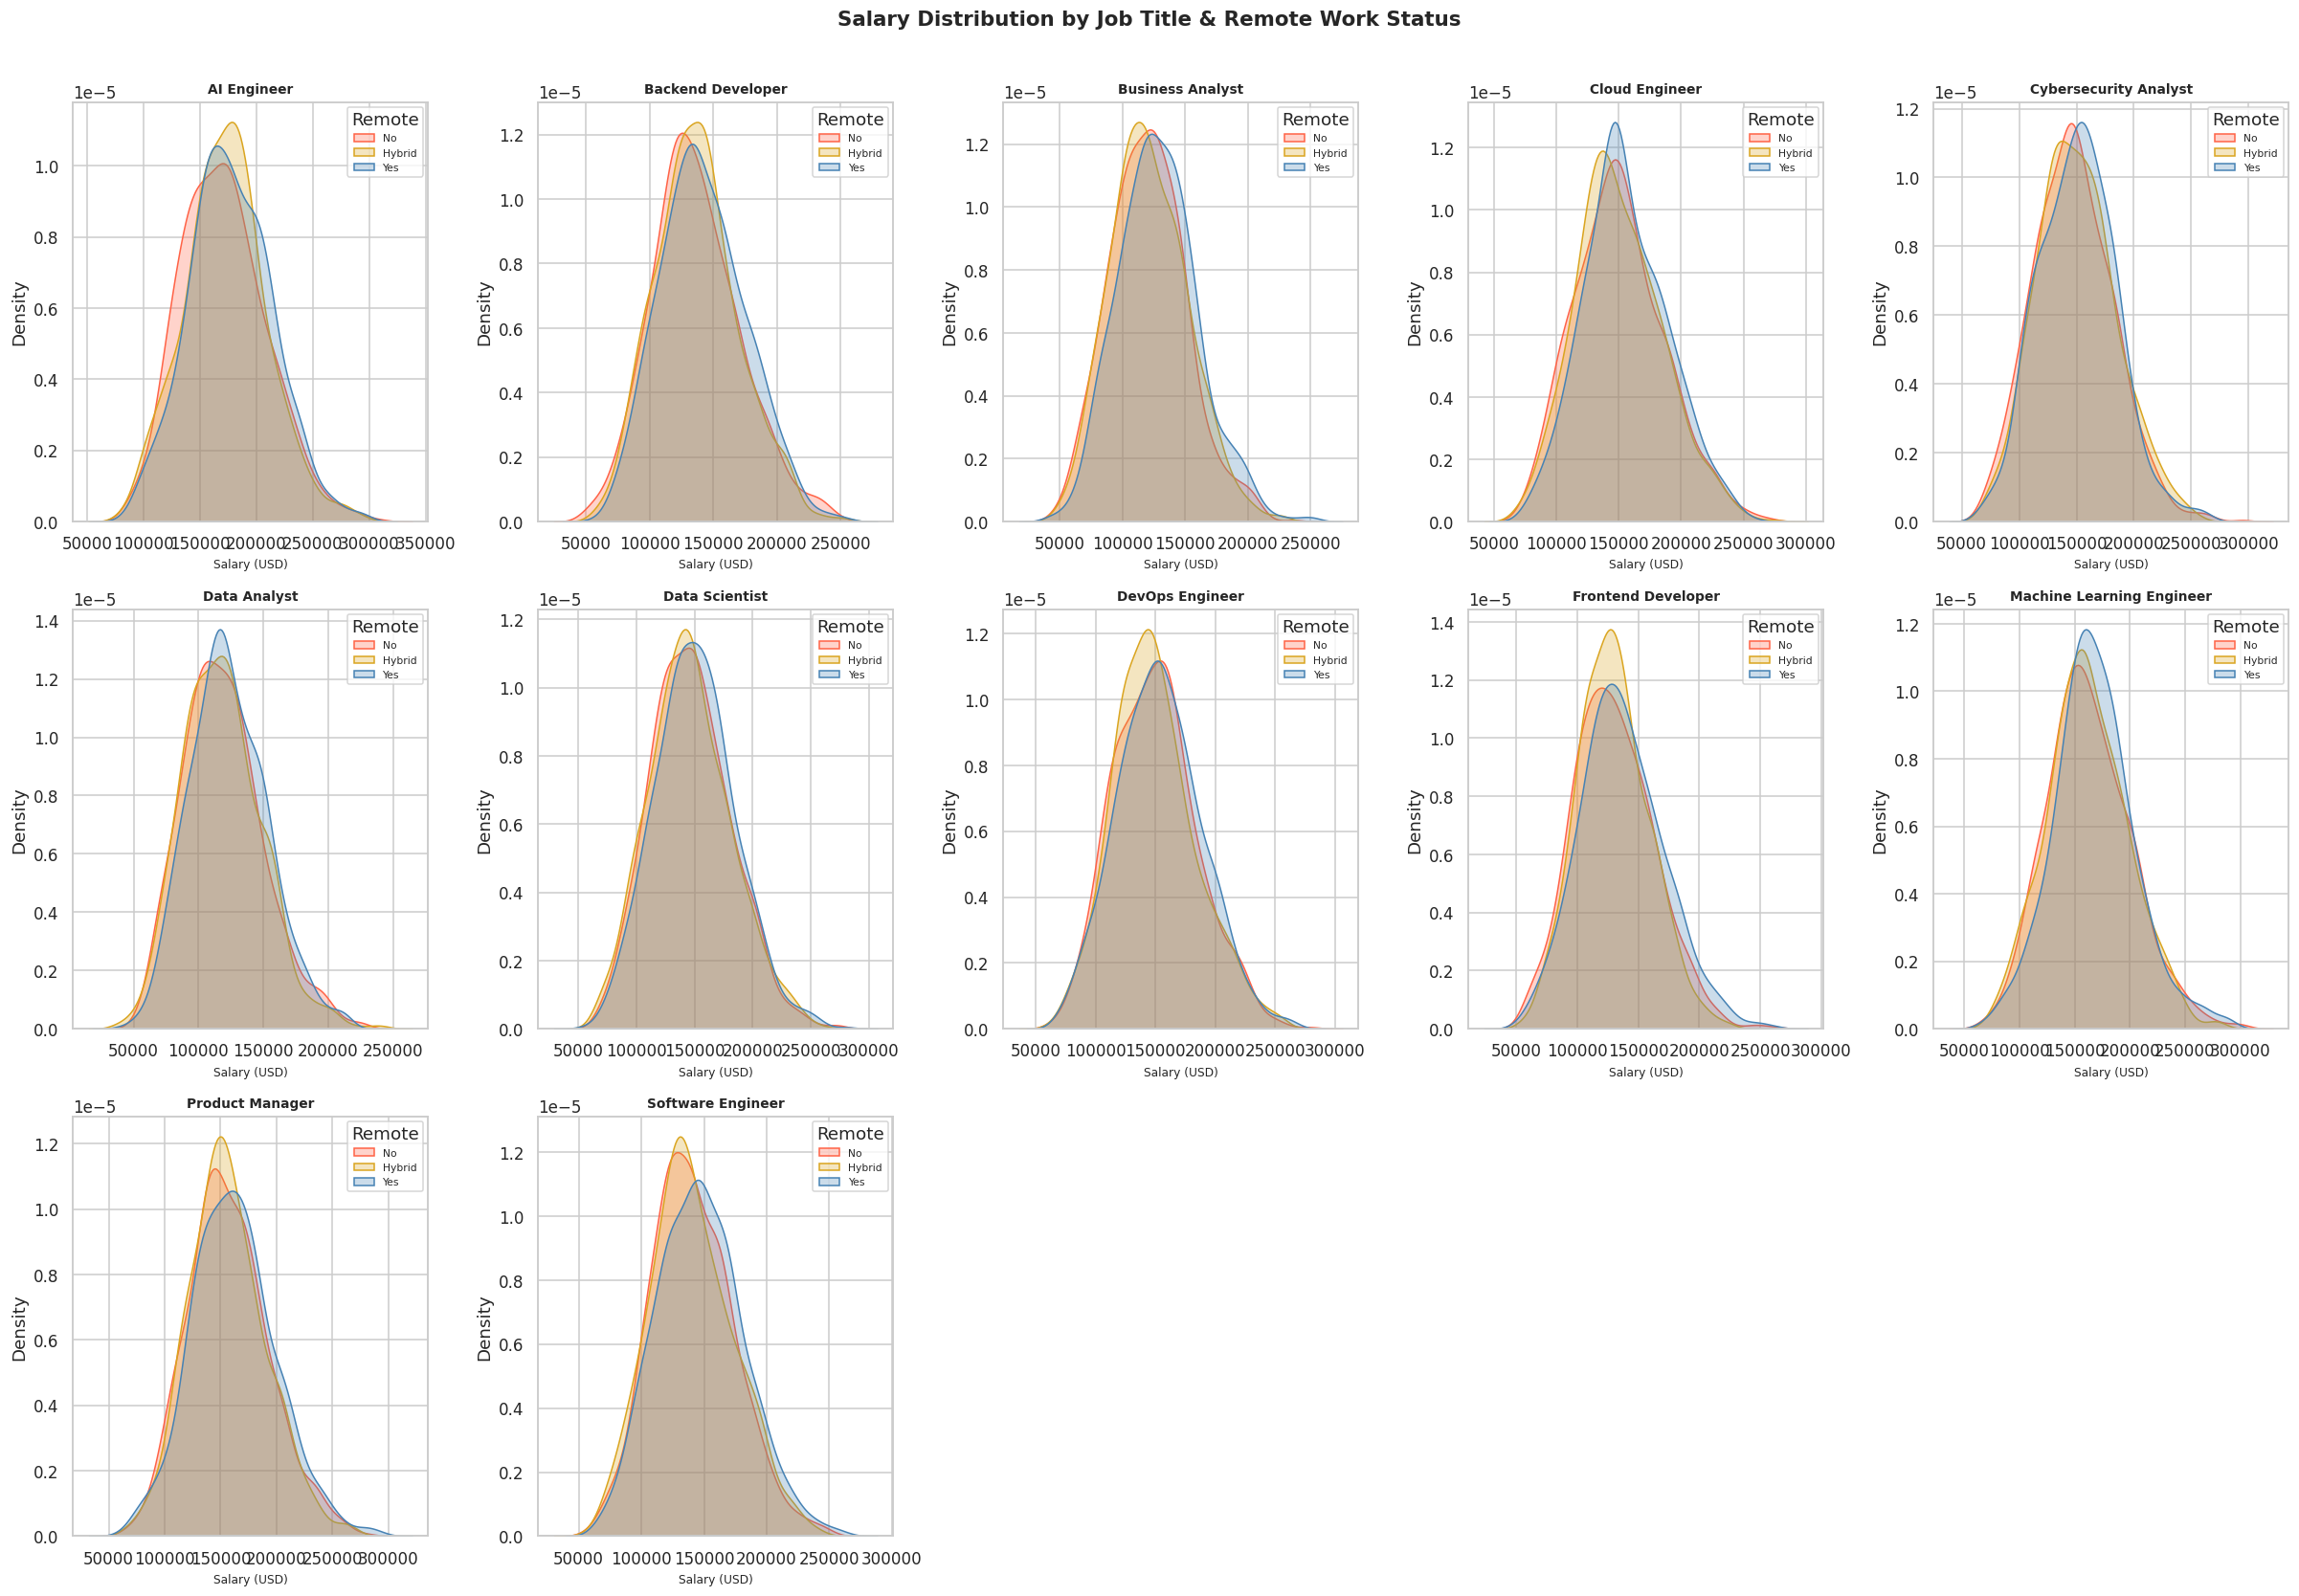

In [ ]:
samp_f   = df[['job_title','remote_work','salary']].dropna()
job_list = sorted(samp_f['job_title'].unique())
palette_r = {'No':'tomato', 'Hybrid':'goldenrod', 'Yes':'steelblue'}
n = len(job_list); ncols = 5; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5*nrows))
axes = axes.flatten()
for i, job in enumerate(job_list):
    jd = samp_f[samp_f['job_title'] == job]
    for rw in ['No','Hybrid','Yes']:
        sub = jd[jd['remote_work'] == rw]['salary']
        if len(sub) > 10:
            sns.kdeplot(sub, ax=axes[i], label=rw,
                        color=palette_r[rw], fill=True, alpha=0.28)
    axes[i].set_title(job, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Salary (USD)', fontsize=8)
    axes[i].legend(title='Remote', fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Salary Distribution by Job Title & Remote Work Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.11 Pair Plot — Multi-Variable Analysis


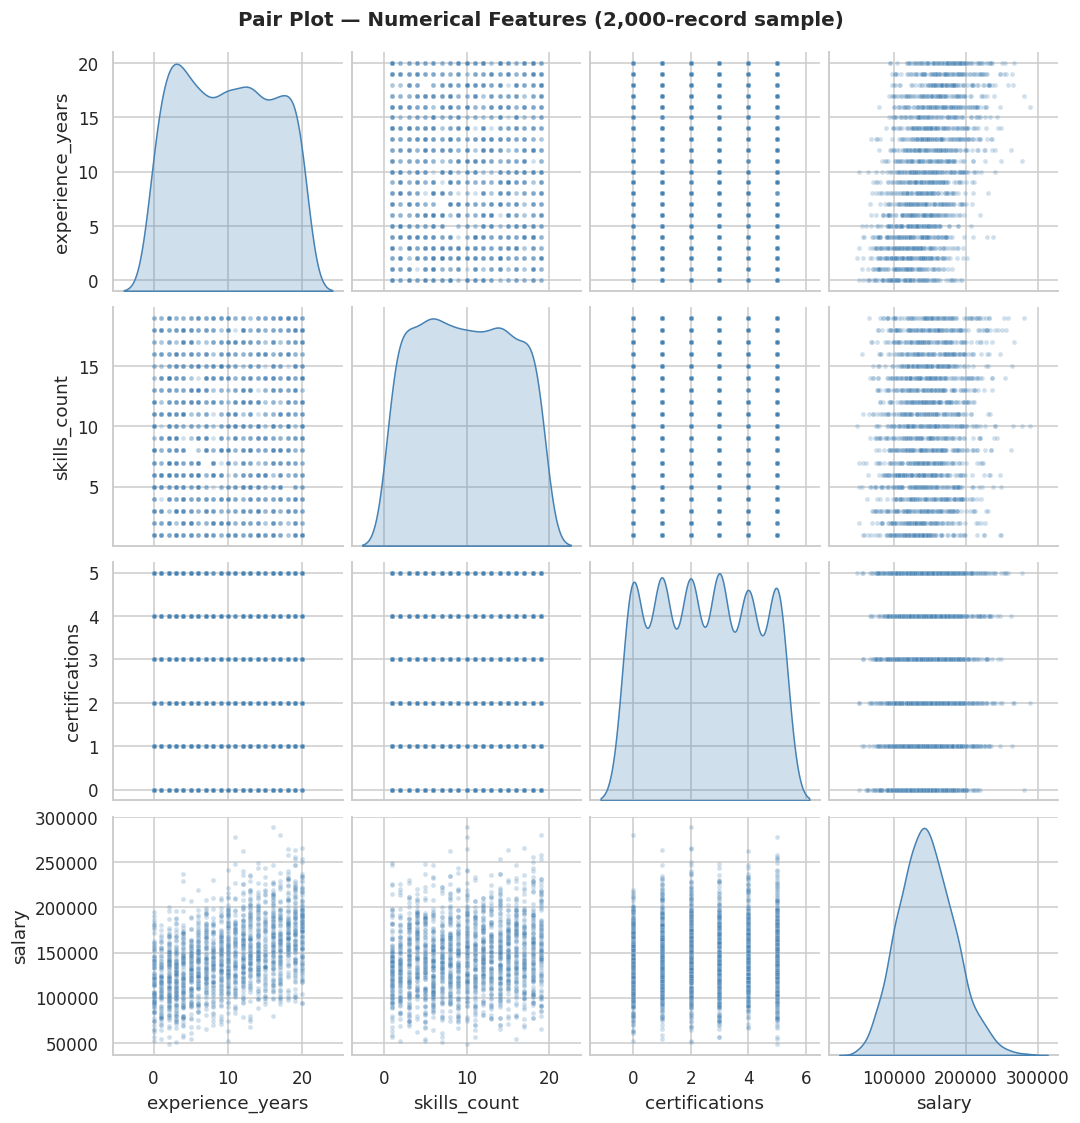

In [ ]:
samp_p = df[['experience_years','skills_count','certifications','salary']].dropna().sample(2000, random_state=42)
g = sns.pairplot(samp_p, diag_kind='kde',
                 plot_kws={'alpha':0.25,'s':10,'color':'steelblue'},
                 diag_kws={'color':'steelblue','fill':True})
g.fig.suptitle('Pair Plot — Numerical Features (2,000-record sample)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## Section 3 — Data Cleaning
### 3.1 Step 1: Drop Rows Where Salary is Missing — Task 3, Q1


In [ ]:
rows_before = len(df)
df_clean    = df.dropna(subset=['salary']).copy()
rows_after  = len(df_clean)
rows_lost   = rows_before - rows_after
pct_lost    = rows_lost / rows_before * 100
print(f"Rows before drop : {rows_before:,}")
print(f"Rows after  drop : {rows_after:,}")
print(f"Rows removed     : {rows_lost:,}")
print(f"Percentage lost  : {pct_lost:.2f}%")

Rows before drop : 275,000
Rows after  drop : 137,851
Rows removed     : 137,149
Percentage lost  : 49.87%


### 3.2 Step 2: Median Imputation for Numerical Columns — Task 3, Q2


In [ ]:
num_impute_cols = ['experience_years', 'skills_count', 'certifications']
for col in num_impute_cols:
    before   = df_clean[col].isnull().sum()
    median_v = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_v)
    print(f"✅ {col:<22} median = {median_v:.1f}  |  {before:,} NaN values filled")

✅ experience_years       median = 10.0  |  68,808 NaN values filled
✅ skills_count           median = 10.0  |  68,885 NaN values filled
✅ certifications         median = 2.0  |  69,282 NaN values filled


### 3.3 Step 3: Mode Imputation for Categorical Columns — Task 3, Q3


In [ ]:
cat_impute_cols = ['job_title','education_level','industry',
                    'company_size','location','remote_work']
for col in cat_impute_cols:
    before  = df_clean[col].isnull().sum()
    mode_v  = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_v)
    print(f"✅ {col:<22} mode = '{mode_v}'  |  {before:,} NaN values filled")

✅ job_title              mode = 'Data Scientist'  |  69,194 NaN values filled
✅ education_level        mode = 'Master'  |  68,915 NaN values filled
✅ industry               mode = 'Healthcare'  |  68,961 NaN values filled
✅ company_size           mode = 'Large'  |  68,788 NaN values filled
✅ location               mode = 'Canada'  |  68,755 NaN values filled
✅ remote_work            mode = 'No'  |  69,100 NaN values filled


### 3.4 Step 4: Verify No Missing Values Remain


In [ ]:
remaining = df_clean.isnull().sum()
total_remaining = remaining.sum()
if total_remaining == 0:
    print("✅ CLEAN! Zero missing values remain across all columns.")
else:
    print("⚠️ Remaining missing:"); print(remaining[remaining>0])
print()
print("Final dataset shape:", df_clean.shape)
print(remaining.to_string())

✅ CLEAN! Zero missing values remain across all columns.

Final dataset shape: (137851, 10)
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0


### 3.5 Cleaning Verification Plots


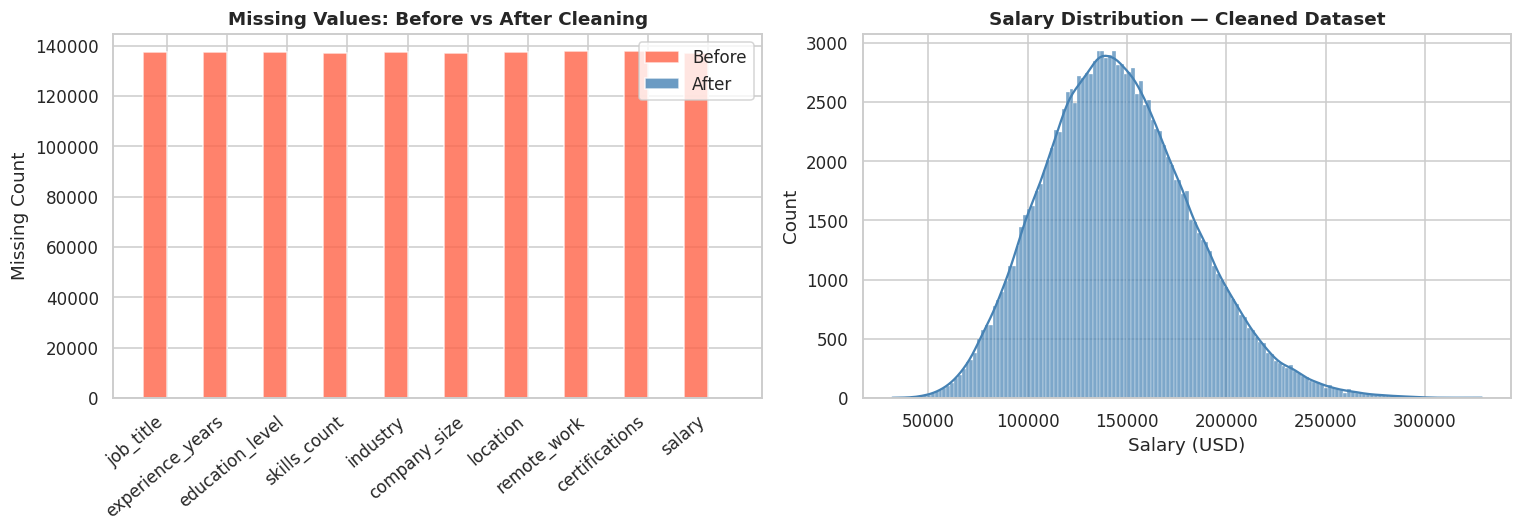

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
before_miss = df.isnull().sum()
after_miss  = df_clean.isnull().sum()
x = range(len(df.columns))
axes[0].bar([i-0.2 for i in x], before_miss.values, 0.4, label='Before', color='tomato', alpha=0.8)
axes[0].bar([i+0.2 for i in x], after_miss.values,  0.4, label='After',  color='steelblue', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df.columns, rotation=40, ha='right')
axes[0].set_title('Missing Values: Before vs After Cleaning', fontweight='bold')
axes[0].set_ylabel('Missing Count'); axes[0].legend()
sns.histplot(df_clean['salary'], kde=True, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Salary Distribution — Cleaned Dataset', fontweight='bold')
axes[1].set_xlabel('Salary (USD)')
plt.tight_layout(); plt.show()

### 3.6 Step 5: Export Cleaned Dataset — Task 3, Q5


In [ ]:
df_clean.to_csv('cleaned_job_data.csv', index=False)
print(f"✅ Saved: cleaned_job_data.csv")
print(f"   Rows    : {df_clean.shape[0]:,}")
print(f"   Columns : {df_clean.shape[1]}")
print(f"   Missing : {df_clean.isnull().sum().sum()}")
print()
print("Sample of cleaned dataset:")
df_clean.head()

✅ Saved: cleaned_job_data.csv
   Rows    : 137,851
   Columns : 10
   Missing : 0

Sample of cleaned dataset:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,Data Scientist,10.0,Master,2.0,Healthcare,Large,Netherlands,No,1.0,120569.0
1,Data Scientist,16.0,Diploma,10.0,Media,Large,Remote,No,2.0,105757.0
2,Data Scientist,18.0,Bachelor,9.0,Manufacturing,Enterprise,Sweden,No,2.0,180750.0
3,Data Scientist,10.0,Master,10.0,Healthcare,Small,Singapore,Hybrid,2.0,101968.0
4,Data Scientist,7.0,Master,10.0,Education,Large,Remote,No,2.0,162627.0
